In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM 

In [3]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x76cc3ce92c20>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x76cc3cd0caf0>, root_client=<openai.OpenAI object at 0x76cc47513df0>, root_async_client=<openai.AsyncOpenAI object at 0x76cc3ce92c50>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the search tools

In [4]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults

arxiv_search = ArxivQueryRun()
tavily_tool = TavilySearchResults(max_results=5)

tools = [arxiv_search, tavily_tool]


### Defining the Graph state

In [5]:
from typing import TypedDict, Annotated, List, Union
from IPython.display import Image, display

In [6]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    input: str
    agent_outcome: Union[AnyMessage, None]
    chat_history: Annotated[list[AnyMessage], add_messages]

### Initialising the workflow(graph)

In [7]:
from langgraph.graph import StateGraph
workflow = StateGraph(AgentState)

### Defining the agent (node) 

In [8]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def research_agent(data):
    print("----research node----")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI research assistant chatbot,"
                " Use the appropriate search tools and chat history to progress towards finding the relevant results."
                " Once you have the relevant search results, summarise them to answer the user query."
                "\nYou have access to the following search tools: {tool_names}."
            ),
            (
                "human",
                "\nUser Query: {input}"
            ),
            
            MessagesPlaceholder(variable_name="chat_history"),
        ]
    )
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    agent = prompt | llm.bind_tools(tools)
    result = agent.invoke(data)
    return {'agent_outcome': [result],
            'chat_history': [result]}

In [9]:
from langgraph.graph import END, StateGraph
workflow = StateGraph(AgentState)

workflow.add_node("research", research_agent)
workflow.set_entry_point("research")

In [10]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        print("----tool calling----")
        message = inputs["agent_outcome"][-1]

        outputs = []
        for tool_call in message.tool_calls:
            print(f"---- Calling {tool_call['name']} with args: {tool_call['args']} ----")
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )

        return {
                "agent_outcome": outputs,
                "chat_history": outputs
            }

tool_node = BasicToolNode(tools=tools)
workflow.add_node("tools", tool_node)

In [11]:
def route_tools(
    state: AgentState,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    print("----router----")
    if isinstance(state, list):
        ai_message = state[-1]
    elif agent_outcome := state.get("agent_outcome", []):
        ai_message = agent_outcome[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [12]:
workflow.add_conditional_edges(
    "research",
    route_tools,
    {"tools": "tools", END: END}
)

In [13]:
workflow.add_edge("tools", "research")

#### Adding Memmory to the chatbot

Langgraph provides checkpointer to automatically save the graph state after each step.

One of the easy way is to use `langgraph.checkpoint.memory.MemorySaver`. This is an in-memory key-value store for graph state.

In [14]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

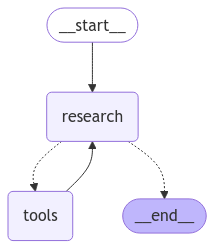

In [15]:
app = workflow.compile(checkpointer=memory)
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

##### Starting Conversation 1

In [16]:
from langchain_core.messages import HumanMessage

inputs = {
    "input": "What are Small Language Models?",
}

config = {
    "configurable": {
        "thread_id": "123",
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])

state = AgentState(**inputs)
events = app.stream(input=state, config=config, stream_mode="values")
for event in events:
    try:
        event["chat_history"][-1].pretty_print()
    except Exception as e:
        pass

================================ Human Message =================================

What are Small Language Models?
----research node----
----router----
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_C2u185yK6UQtK5qgmZgpMJkp)
 Call ID: call_C2u185yK6UQtK5qgmZgpMJkp
  Args:
    query: Small Language Models
----tool calling----
---- Calling arxiv with args: {'query': 'Small Language Models'} ----
================================= Tool Message =================================
Name: arxiv

"Published: 2022-01-26\nTitle: An Assessment of the Impact of OCR Noise on Language Models\nAuthors: Konstantin Todorov, Giovanni Colavizza\nSummary: Neural language models are the backbone of modern-day natural language\nprocessing applications. Their use on textual heritage collections which have\nundergone Optical Character Recognition (OCR) is therefore also increasing.\nNevertheless, our understanding of the impact OCR noise could have on la

In [17]:
inputs = {
    "input": "Summarise the results into a single paragraph.",
}
inputs["chat_history"] = HumanMessage(inputs["input"])
state = AgentState(**inputs)
events = app.stream(input=state, config=config, stream_mode="values")
for event in events:
    try:
        event["chat_history"][-1].pretty_print()
    except Exception as e:
        pass

================================ Human Message =================================

Summarise the results into a single paragraph.
----research node----
----router----
================================== Ai Message ==================================

Small Language Models (SLMs) are compact language models that can outperform larger models in scenarios with limited or noisy data, such as when dealing with Optical Character Recognition (OCR) noise, where simpler models like PPMI and Word2Vec have shown better performance than transformer-based models. They are particularly advantageous for low-resource languages, as demonstrated by a study that employed a three-stage continual training approach to develop a large generative model for Norwegian and Northern Sámi. Additionally, while SLMs may struggle with capturing long-distance dependencies and can overfit to training data, contrasting their attention mechanisms with larger models can uncover important insights for enhancing knowledge lear

In [18]:
snapshot = app.get_state(config=config)
snapshot.values

{'input': 'Summarise the results into a single paragraph.',
 'agent_outcome': [AIMessage(content='Small Language Models (SLMs) are compact language models that can outperform larger models in scenarios with limited or noisy data, such as when dealing with Optical Character Recognition (OCR) noise, where simpler models like PPMI and Word2Vec have shown better performance than transformer-based models. They are particularly advantageous for low-resource languages, as demonstrated by a study that employed a three-stage continual training approach to develop a large generative model for Norwegian and Northern Sámi. Additionally, while SLMs may struggle with capturing long-distance dependencies and can overfit to training data, contrasting their attention mechanisms with larger models can uncover important insights for enhancing knowledge learning efficiency. Overall, SLMs are effective tools for specific tasks and languages, especially when data availability is a concern.', additional_kwar

##### Starting Conversation 2

In [19]:
inputs = {
    "input": "What are the recent papers on LLM Agents?",
}

config_new = {
    "configurable": {
        "thread_id": "456",
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])

state = AgentState(**inputs)
events = app.stream(input=state, config=config_new, stream_mode="values")
for event in events:
    try:
        event["chat_history"][-1].pretty_print()
    except Exception as e:
        pass
    

================================ Human Message =================================

What are the recent papers on LLM Agents?
----research node----
----router----
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_a9VXE0nlDUFFiaAnnR4Bk6MZ)
 Call ID: call_a9VXE0nlDUFFiaAnnR4Bk6MZ
  Args:
    query: LLM Agents
----tool calling----
---- Calling arxiv with args: {'query': 'LLM Agents'} ----
================================= Tool Message =================================
Name: arxiv

"Published: 2024-09-27\nTitle: Exploring Prosocial Irrationality for LLM Agents: A Social Cognition View\nAuthors: Xuan Liu, Jie Zhang, Song Guo, Haoyang Shang, Chengxu Yang, Quanyan Zhu\nSummary: Large language models (LLMs) have been shown to face hallucination issues due\nto the data they trained on often containing human bias; whether this is\nreflected in the decision-making process of LLM Agents remains under-explored.\nAs LLM Agents are increasingly e

In [20]:
inputs = {
    "input": "Can you find LLM Agents for report or article generation?",
}
inputs["chat_history"] = HumanMessage(inputs["input"])
state = AgentState(**inputs)
events = app.stream(input=state, config=config_new, stream_mode="values")
for event in events:
    try:
        event["chat_history"][-1].pretty_print()
    except Exception as e:
        pass

================================ Human Message =================================

Can you find LLM Agents for report or article generation?
----research node----
----router----
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_ZiEkjjLMI2ZhkWXMw8Lexh6s)
 Call ID: call_ZiEkjjLMI2ZhkWXMw8Lexh6s
  Args:
    query: LLM Agents for report or article generation
----tool calling----
---- Calling tavily_search_results_json with args: {'query': 'LLM Agents for report or article generation'} ----
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.llamaindex.ai/blog/building-blocks-of-llm-report-generation-beyond-basic-rag", "content": "Building Blocks of LLM Report Generation: Beyond Basic RAG \u2014 LlamaIndex - Build Knowledge Assistants over your Enterprise Data Based on common enterprise use cases like financial analysis reports, RF

In [21]:
snapshot = app.get_state(config=config_new)
snapshot.values

{'input': 'Can you find LLM Agents for report or article generation?',
 'agent_outcome': [AIMessage(content='Here are some resources and articles related to LLM Agents for report or article generation:\n\n1. **Building Blocks of LLM Report Generation: Beyond Basic RAG** - [LlamaIndex](https://www.llamaindex.ai/blog/building-blocks-of-llm-report-generation-beyond-basic-rag)\n   - This article discusses how LLMs can automate the initial drafting and formatting of reports, potentially saving 10-15 hours per report. It emphasizes the evolution from basic retrieval-augmented generation (RAG) applications to sophisticated knowledge assistants capable of comprehensive report generation.\n\n2. **The RGD Framework** - [arXiv](https://arxiv.org/abs/2410.01242)\n   - This paper introduces the RGD framework, which utilizes multiple LLM agents (Guide Agent, Debug Agent, and Feedback Agent) to streamline the code generation process. It highlights the benefits of breaking down tasks into manageable s

In [22]:
inputs = {
    "input": "Summarise all the papers like survey report.",
}

inputs["chat_history"] = HumanMessage(inputs["input"])

state = AgentState(**inputs)
events = app.stream(input=state, config=config_new, stream_mode="values")
for event in events:
    try:
        event["chat_history"][-1].pretty_print()
    except Exception as e:
        pass

================================ Human Message =================================

Summarise all the papers like survey report.
----research node----
----router----
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_CO7QZzokUxTR0vWE65xVNtBI)
 Call ID: call_CO7QZzokUxTR0vWE65xVNtBI
  Args:
    query: LLM Agents for report generation
  arxiv (call_kCR7Q6DpT4SU1IWQR4JkX5OT)
 Call ID: call_kCR7Q6DpT4SU1IWQR4JkX5OT
  Args:
    query: LLM Agents article generation
----tool calling----
---- Calling arxiv with args: {'query': 'LLM Agents for report generation'} ----
---- Calling arxiv with args: {'query': 'LLM Agents article generation'} ----
================================= Tool Message =================================
Name: arxiv

"Published: 2023-07-06\nTitle: Wireless Multi-Agent Generative AI: From Connected Intelligence to Collective Intelligence\nAuthors: Hang Zou, Qiyang Zhao, Lina Bariah, Mehdi Bennis, Merouane Debbah\nSummary: 

In [23]:
snapshot = app.get_state(config=config_new)
snapshot.values

{'input': 'Summarise all the papers like survey report.',
 'agent_outcome': [AIMessage(content='Here is a summary of recent papers related to LLM Agents, particularly focusing on their applications in report and article generation:\n\n1. **Enhancing LLMs for Impression Generation in Radiology Reports through a Multi-Agent System** (Published: 2024-12-06)\n   - **Authors**: Fang Zeng, Zhiliang Lyu, et al.\n   - **Summary**: This study presents "RadCouncil," a multi-agent framework designed to improve the generation of impressions in radiology reports. It consists of three agents: a Retrieval Agent for finding similar reports, a Radiologist Agent for generating impressions, and a Reviewer Agent for evaluating the output. The framework showed significant improvements in diagnostic accuracy and clarity compared to single-agent approaches.\n\n2. **Spontaneous Emergence of Agent Individuality through Social Interactions in LLM-Based Communities** (Published: 2024-11-05)\n   - **Authors**: Ry

##### Switching back to conversation 1

In [24]:
inputs = {
    "input": "What is the research topic?",
}
inputs["chat_history"] = HumanMessage(inputs["input"])
state = AgentState(**inputs)
events = app.stream(input=state, config=config, stream_mode="values")
for event in events:
    try:
        event["agent_outcome"][-1].pretty_print()
    except Exception as e:
        pass
    print("-----"*20)

================================== Ai Message ==================================

Small Language Models (SLMs) are compact language models that can outperform larger models in scenarios with limited or noisy data, such as when dealing with Optical Character Recognition (OCR) noise, where simpler models like PPMI and Word2Vec have shown better performance than transformer-based models. They are particularly advantageous for low-resource languages, as demonstrated by a study that employed a three-stage continual training approach to develop a large generative model for Norwegian and Northern Sámi. Additionally, while SLMs may struggle with capturing long-distance dependencies and can overfit to training data, contrasting their attention mechanisms with larger models can uncover important insights for enhancing knowledge learning efficiency. Overall, SLMs are effective tools for specific tasks and languages, especially when data availability is a concern.
---------------------------------

In [25]:
snapshot = app.get_state(config=config)
snapshot.values

{'input': 'What is the research topic?',
 'agent_outcome': [AIMessage(content='The research topic revolves around "Small Language Models" (SLMs), focusing on their performance, training methodologies, and applications, particularly in contexts with limited or noisy data, as well as their effectiveness for low-resource languages. The studies explore how SLMs can outperform larger models in certain scenarios, the techniques for continual training, and the implications of their attention mechanisms on knowledge learning efficiency.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 1448, 'total_tokens': 1527, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72ed7ab54c', 'finish_reason': 'stop', 'logprobs':